In [1]:
# Importação da base de dados
import os
import kagglehub

# Manipulação de dados
import pandas as pd
import numpy as np
import time

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    ConfusionMatrixDisplay
)

# Desbalanceamento
from imblearn.over_sampling import SMOTE

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configurações de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports realizados com sucesso!')

Imports realizados com sucesso!


In [2]:
# Download do dataset
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Path to dataset files:", path)

# Localizar o arquivo CSV dentro da pasta baixada
files = os.listdir(path)
print("Arquivos disponíveis:", files)

# Carregar o CSV
df = pd.read_csv(os.path.join(path, files[0]))

print(f'Shape: {df.shape}')
df.head()

Path to dataset files: C:\Users\Felipe\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1
Arquivos disponíveis: ['UCI_Credit_Card.csv']
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
# Remover coluna identificadora
df.drop(columns=['ID'], inplace=True)

# Padronizar nome da variável-alvo
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

print('Colunas após limpeza:')
print(df.columns.tolist())

Colunas após limpeza:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [4]:
print('=== Informações gerais ===')
df.info()

print('\n=== Valores ausentes por coluna ===')
print(df.isnull().sum())

=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_0      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 no

In [5]:
# Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [6]:
print('Antes do tratamento:')
print('EDUCATION:', df['EDUCATION'].value_counts().sort_index().to_dict())
print('MARRIAGE: ', df['MARRIAGE'].value_counts().sort_index().to_dict())

# Agrupar categorias não documentadas em 'outros' (4 e 3 respectivamente)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})

print('\nApós tratamento:')
print('EDUCATION:', df['EDUCATION'].value_counts().sort_index().to_dict())
print('MARRIAGE: ', df['MARRIAGE'].value_counts().sort_index().to_dict())

Antes do tratamento:
EDUCATION: {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE:  {0: 54, 1: 13659, 2: 15964, 3: 323}

Após tratamento:
EDUCATION: {1: 10585, 2: 14030, 3: 4917, 4: 468}
MARRIAGE:  {1: 13659, 2: 15964, 3: 377}


In [7]:
X = df.drop(columns=['default'])
y = df['default']

# Divisão treino+val / teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Divisão treino / validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), random_state=SEED, stratify=y_temp
)

print(f'Treino:    {X_train.shape[0]:>6} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Validação: {X_val.shape[0]:>6} registros ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Teste:     {X_test.shape[0]:>6} registros ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nProporção de default — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}')

Treino:     21000 registros (70.0%)
Validação:   4500 registros (15.0%)
Teste:       4500 registros (15.0%)

Proporção de default — treino: 0.221 | teste: 0.221


In [8]:
# Normalização — fit apenas no treino
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Normalização concluída.')
print(f'Média no treino (esperado ~0): {X_train_sc.mean():.4f}')
print(f'Desvio padrão no treino (esperado ~1): {X_train_sc.std():.4f}')

Normalização concluída.
Média no treino (esperado ~0): -0.0000
Desvio padrão no treino (esperado ~1): 1.0000


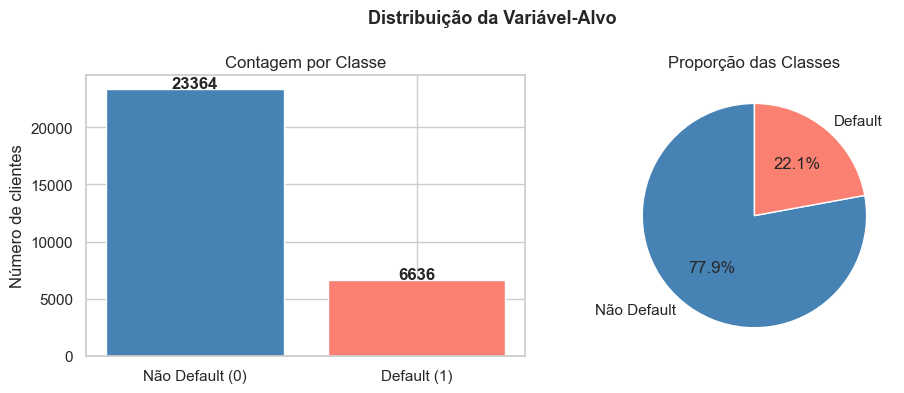

Proporção de default: 22.12%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = y.value_counts()
axes[0].bar(['Não Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Não Default', 'Default'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporção das Classes')

plt.suptitle('Distribuição da Variável-Alvo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Proporção de default: {y.mean():.2%}')

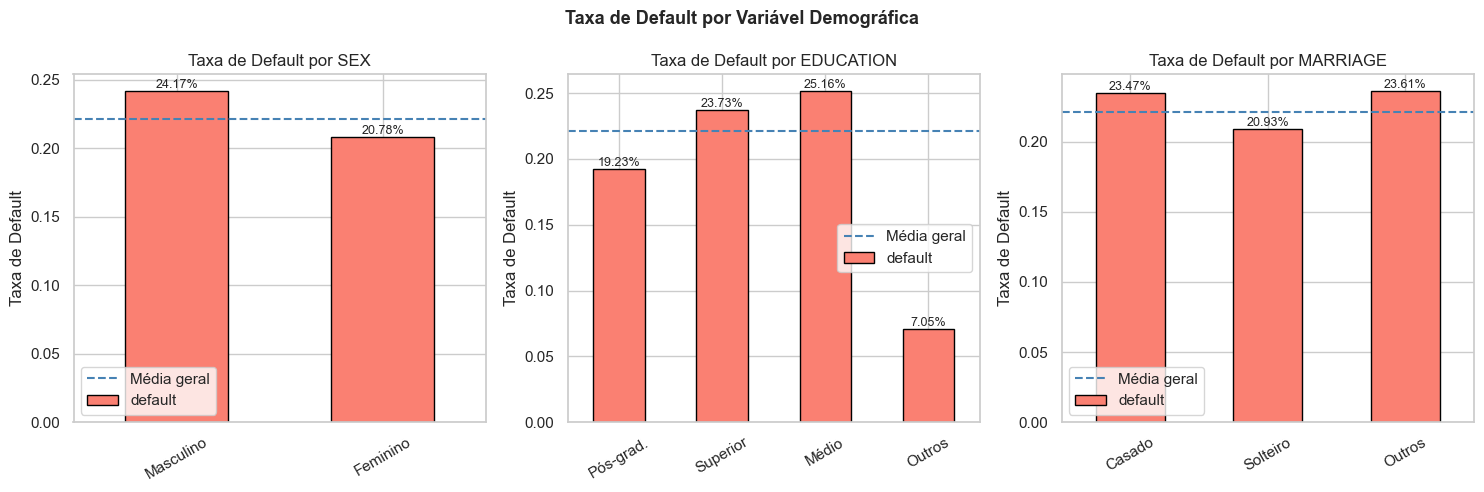

In [10]:
demo_vars = {
    'SEX':       {1: 'Masculino', 2: 'Feminino'},
    'EDUCATION': {1: 'Pós-grad.', 2: 'Superior', 3: 'Médio', 4: 'Outros'},
    'MARRIAGE':  {1: 'Casado', 2: 'Solteiro', 3: 'Outros'}
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, labels) in zip(axes, demo_vars.items()):
    default_rate = df.groupby(col)['default'].mean().rename(index=labels)
    default_rate.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(f'Taxa de Default por {col}')
    ax.set_ylabel('Taxa de Default')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y.mean(), color='steelblue', linestyle='--', label='Média geral')
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Taxa de Default por Variável Demográfica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

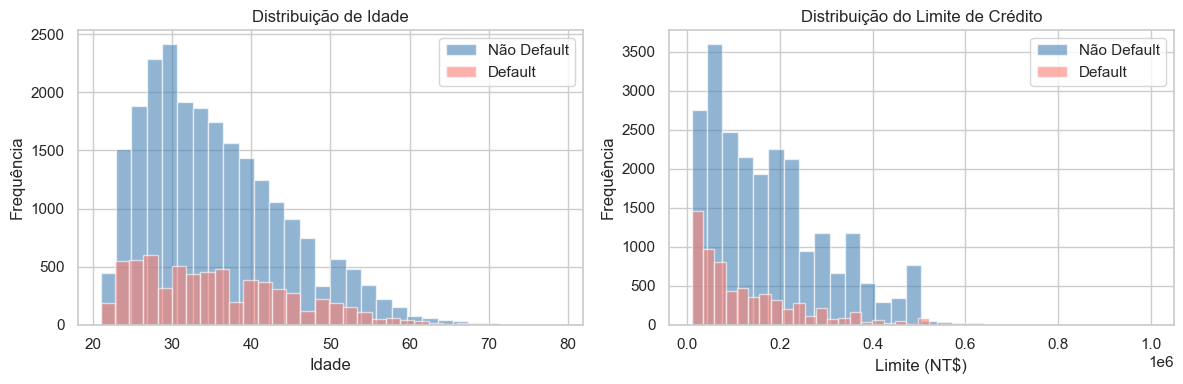

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in [(0, 'Não Default', 'steelblue'), (1, 'Default', 'salmon')]:
    subset = df[df['default'] == val]
    axes[0].hist(subset['AGE'], bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].hist(subset['LIMIT_BAL'], bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Distribuição de Idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].set_title('Distribuição do Limite de Crédito')
axes[1].set_xlabel('Limite (NT$)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

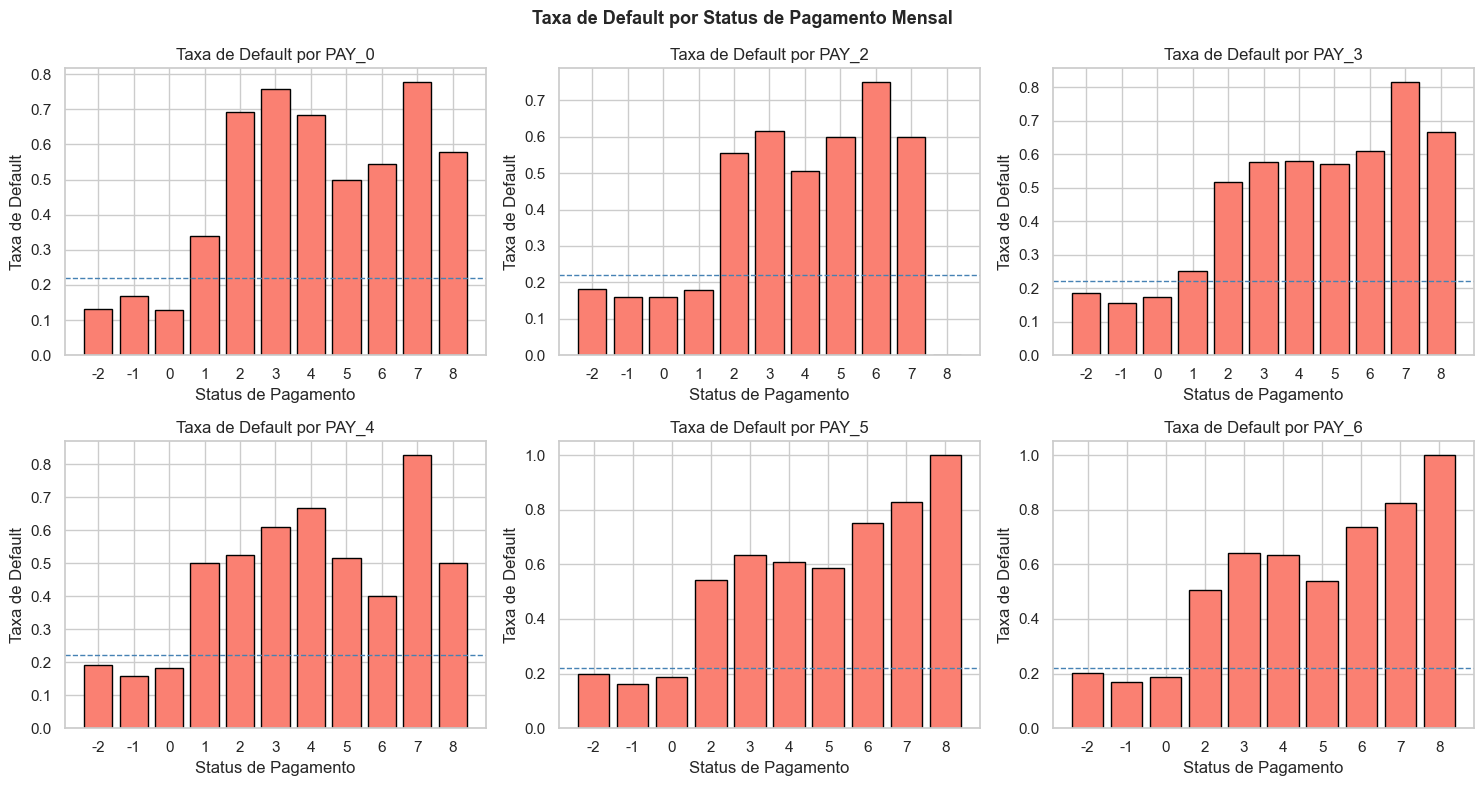

In [12]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    default_rate = df.groupby(col)['default'].mean()
    axes[i].bar(default_rate.index.astype(str), default_rate.values, color='salmon', edgecolor='black')
    axes[i].set_title(f'Taxa de Default por {col}')
    axes[i].set_xlabel('Status de Pagamento')
    axes[i].set_ylabel('Taxa de Default')
    axes[i].axhline(y.mean(), color='steelblue', linestyle='--', linewidth=1)

plt.suptitle('Taxa de Default por Status de Pagamento Mensal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

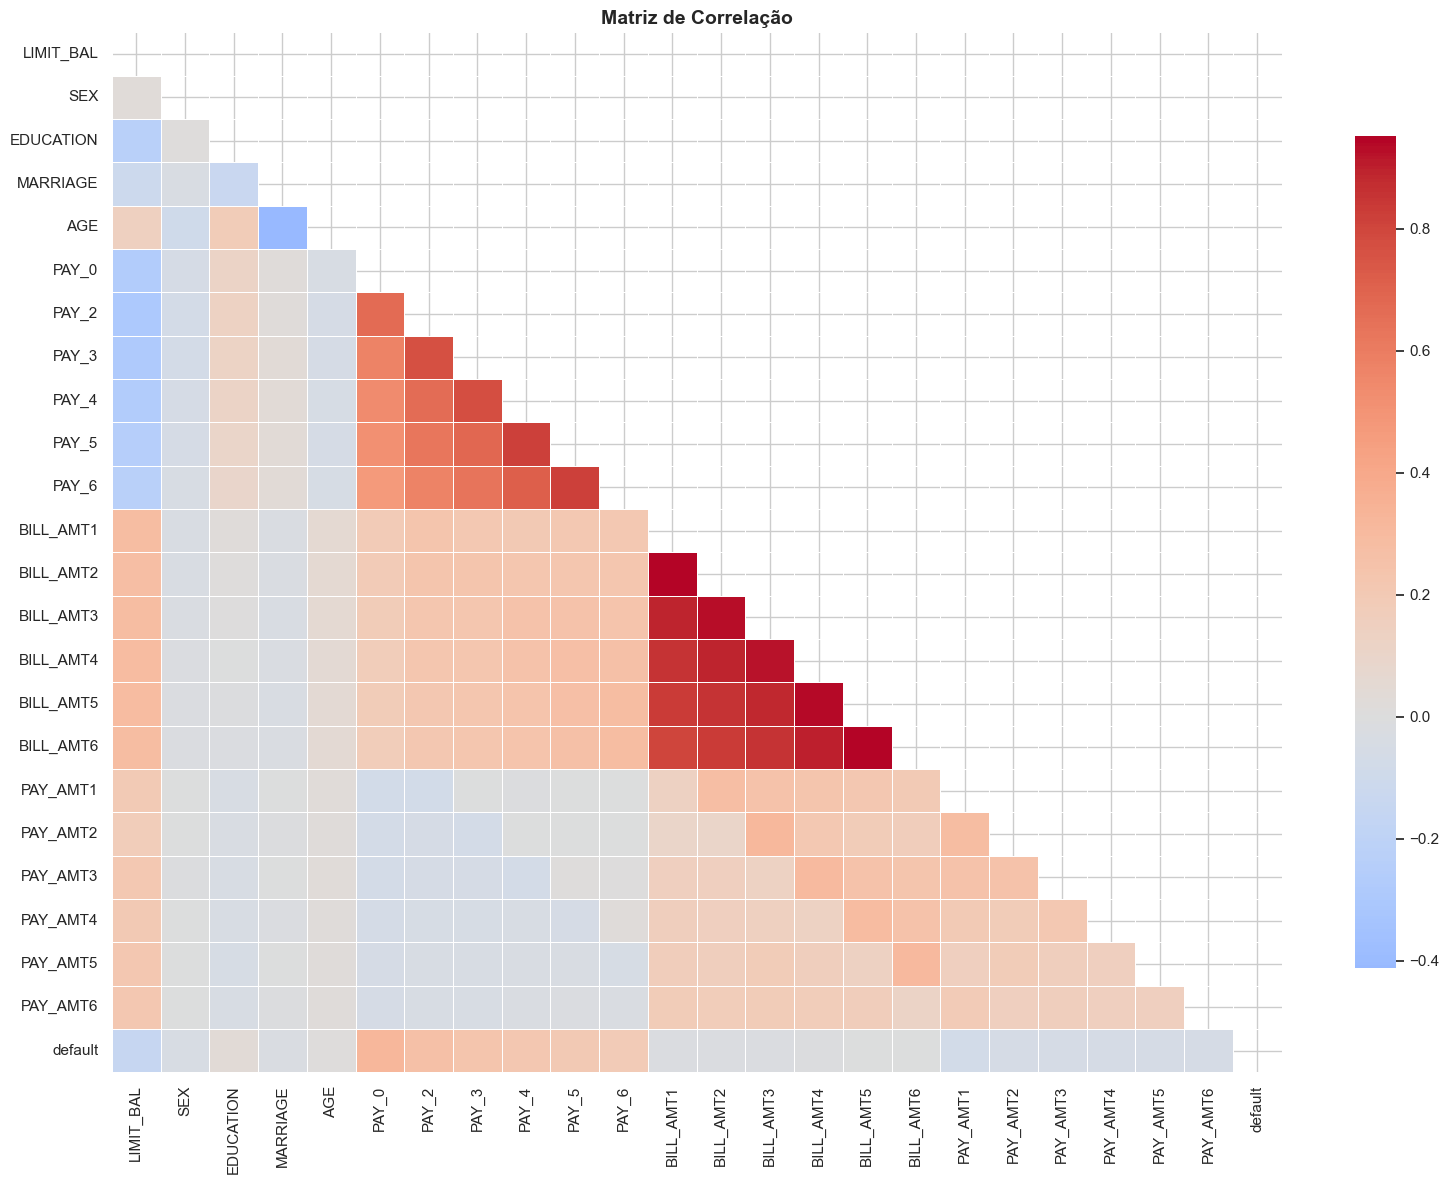

=== Top 10 correlações com default ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default, dtype: float64


In [13]:
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlações com a variável-alvo
print('=== Top 10 correlações com default ===')
print(corr['default'].drop('default').abs().sort_values(ascending=False).head(10))

In [14]:
models = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'
    ),
    'Árvore de Decisão': DecisionTreeClassifier(
        max_depth=6, random_state=SEED, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=SEED, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
}

print('Modelos definidos:')
for name in models:
    print(f'  - {name}')

Modelos definidos:
  - Regressão Logística
  - Árvore de Decisão
  - Random Forest
  - XGBoost


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, model in models.items():
    # Modelos lineares usam dados normalizados
    X_cv = X_train_sc if name == 'Regressão Logística' else X_train

    start = time.time()
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    elapsed = time.time() - start

    cv_results[name] = {
        'AUC-ROC médio': scores.mean(),
        'Desvio padrão': scores.std(),
        'Tempo (s)': round(elapsed, 1)
    }
    print(f'{name:<25} AUC-ROC: {scores.mean():.4f} ± {scores.std():.4f}  |  Tempo: {elapsed:.1f}s')

cv_df = pd.DataFrame(cv_results).T
print('\n', cv_df)

Regressão Logística       AUC-ROC: 0.7253 ± 0.0124  |  Tempo: 8.7s
Árvore de Decisão         AUC-ROC: 0.7563 ± 0.0074  |  Tempo: 5.9s
Random Forest             AUC-ROC: 0.7640 ± 0.0111  |  Tempo: 7.5s
XGBoost                   AUC-ROC: 0.7552 ± 0.0113  |  Tempo: 1.6s

                      AUC-ROC médio  Desvio padrão  Tempo (s)
Regressão Logística       0.725261       0.012428        8.7
Árvore de Decisão         0.756269       0.007357        5.9
Random Forest             0.764008       0.011133        7.5
XGBoost                   0.755168       0.011297        1.6
